# Spatial figures — simple workflow

1. Load one recording with a `DataStructure`.
2. Select the data for each figure with the slicing API.
3. Define the measurement and plotting functions.
4. Call those functions to return figures.

Use the project Python environment with `src` on its import path. Positions stay
in video pixels and times stay on the recording clock. DLC confidence below 0.9
is masked; positions are not interpolated or smoothed.

In [1]:
# 1 | Configure the DataStructure and load one recording
from pathlib import Path

import matplotlib.pyplot as plt
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from movement.utils.vector import compute_signed_angle_2d

from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from movement_figures.data_template.loading import build_datastructure
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries
from movement_figures.video import read_session_video_frame

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
SESSION = "2026-06-21T093349Z"
data = build_datastructure(
    ROOT, level_names=("mouseID", "day"),
    l0_selector="MR_M01569515", l1_selector="Day21", include=(SESSION,),
    streams=("trials", "dlc"),
)
streams = data.load()
session_id, session_ref = next(iter(data.sessions.items()))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


In [11]:
print(session_id)
print(session_ref)

2026-06-21T093349Z
SessionRef(path=PosixPath('/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training/MR_M01569515/Day21/2026-06-21T093349Z'), levels={'mouseID': 'MR_M01569515', 'day': 'Day21'}, metadata={'label': '2026-06-21T093349Z'})


## 2. Select figure inputs

The angle figure uses the **first selected trial**. Occupancy uses **trials 1–8**,
with separate outbound and inbound panels. Change the explicit `trial_index`
slice below to choose another range; both bounds are inclusive.

The static ROI is **North / top of video**, the top-centre pixel of the first
undistorted frame. Nosepoke numbers do not provide pixel coordinates; a measured
nosepoke `(x, y)` can replace `fixed_roi_px` directly.

In [2]:
# 2.1 | Select this recording's pose and requested original trial indices
pose = pose_to_movement(
    slice_stream(streams["dlc:position"], selectors={"session": session_id}),
    slice_stream(streams["dlc:confidence"], selectors={"session": session_id}),
)
position = pose.position.where(pose.confidence >= 0.9).sel(
    individual="individual_0", drop=True,
)
selected_trials = slice_stream(
    streams["trials"], selectors={"session": session_id, "trial_index": slice(1, 8)},
)
angle_trials = selected_trials.iloc[:1]
angle_positions = slice_stream_for_trial(
    position, angle_trials.iloc[0], time_coord="time",
)

# 2.2 | Load the matching video's first frame and define its top-centre ROI
background_frame, video_path = read_session_video_frame(
    session_ref.path, video_subdir="UndistortedVideoData",
)
frame_height, frame_width = background_frame.shape[:2]
fixed_roi_px = np.array([(frame_width - 1) / 2, 0.0])
fixed_roi_label = "North / top of video"

In [3]:
# 2.3 | Slice selected trials and their phases for body-position occupancy
point = position.sel(keypoint="body", drop=True)
selected = xr.zeros_like(point.time, dtype=bool)
outbound = xr.zeros_like(point.time, dtype=bool)
inbound = xr.zeros_like(point.time, dtype=bool)

for _, trial in selected_trials.iterrows():
    trial_point = slice_stream_for_trial(point, trial, time_coord="time")
    selected |= point.time.isin(trial_point.time)

    # A missing or unordered target cannot define outbound and inbound phases.
    start, target, end = trial[["start_time", "tz_triggered_time", "end_time"]]
    if not pd.notna([start, target, end]).all() or not start < target < end:
        continue
    outbound_trial = trial.copy()
    outbound_trial["end_time"] = target
    outbound_trial["end_inclusive"] = False  # Target belongs only to inbound.
    inbound_trial = trial.copy()
    inbound_trial["start_time"] = target
    inbound_trial["start_inclusive"] = True
    outbound_point = slice_stream_for_trial(point, outbound_trial, time_coord="time")
    inbound_point = slice_stream_for_trial(point, inbound_trial, time_coord="time")
    outbound |= point.time.isin(outbound_point.time)
    inbound |= point.time.isin(inbound_point.time)

# Keep the recording clock; excluded samples remain NaN between selected trials.
occupancy_points = {
    "Selected trials": point.where(selected),
    "Outbound": point.where(outbound),
    "Inbound": point.where(inbound),
}
selected_trials

,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,False,True,43,56,5707.698976,5697.756000,0,...,5707.698976,False,True,5707.698976,5709.933824,True,True,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,False,True,57,71,5719.708992,5719.392000,0,...,5719.708992,False,True,5719.708992,5721.442080,True,True,2026-06-21T093349Z,MR_M01569515,Day21
5,6,5721.442080,5727.532608,False,True,72,85,5726.500992,5723.960000,0,...,5726.500992,False,True,5726.500992,5727.532608,True,True,2026-06-21T093349Z,MR_M01569515,Day21
6,7,5727.532608,5736.700960,False,True,86,100,5735.050976,5734.158976,0,...,5735.050976,False,True,5735.050976,5736.700960,True,True,2026-06-21T093349Z,MR_M01569515,Day21
7,8,5736.700960,5743.183072,False,True,101,114,5741.900992,5739.190976,0,...,5741.900992,False,True,5741.900992,5743.183072,True,True,2026-06-21T093349Z,MR_M01569515,Day21


## 3. Define measurements and figure functions

Allocentric heading is measured from image-right to head-forward. Positive angles
are clockwise because image y increases downward. ROI bearing is measured from
head-forward towards **ROI minus ear midpoint**: zero means straight ahead.
Missing positions and zero-length direction vectors give undefined angles.

Occupancy counts valid position samples in shared rectangular bins spanning the
video. These are **sample counts**, not dwell seconds or probabilities. Outbound
and inbound have different durations. The target sample belongs to inbound;
outer trial boundaries retain the trial table's inclusion flags. Trials without a
usable target remain in the selected-trials panel but contribute to neither phase.

In [4]:
# 3.1 | Define head-direction and static-target measurements

def compute_head_angles(position, fixed_roi_px, *, left_ear="lear", right_ear="rear"):
    """Measure allocentric heading and bearing towards a static pixel point.

    Parameters
    ----------
    position : xarray.DataArray
        Selected (time, space, keypoint) positions for one animal; space is x/y.
    fixed_roi_px : array-like
        Static target (x, y) in the same video pixels as position.
    left_ear, right_ear : str
        Ear keypoint names, using the top-down camera convention.

    Returns
    -------
    xarray.Dataset
        allocentric_heading and fixed_roi_bearing in radians on the input clock.
        Both lie in [-pi, pi]; undefined directions remain NaN.
    """
    # --- Head-forward is perpendicular to the left-to-right ear vector. ---
    left = position.sel(keypoint=left_ear, drop=True)
    right = position.sel(keypoint=right_ear, drop=True)
    valid_head = ((left - right) ** 2).sum("space", skipna=False) > 0
    head_forward = kin.compute_head_direction_vector(
        position, left_keypoint=left_ear, right_keypoint=right_ear,
        camera_view="top_down",
    ).where(valid_head)
    allocentric = kin.compute_forward_vector_angle(
        position, left_keypoint=left_ear, right_keypoint=right_ear,
        reference_vector=(1.0, 0.0), camera_view="top_down",
    ).where(valid_head)

    # --- A bearing uses the animal-to-target vector, not a fixed compass angle. ---
    target = xr.DataArray(fixed_roi_px, dims="space", coords={"space": ["x", "y"]})
    to_target = target - (left + right) / 2
    target_separated = (to_target ** 2).sum("space", skipna=False) > 0
    bearing = compute_signed_angle_2d(head_forward, to_target).where(target_separated)
    return xr.Dataset({"allocentric_heading": allocentric, "fixed_roi_bearing": bearing})

In [5]:
# 3.2 | Define the annotated angle figure

def plot_head_angles(angles, trials, *, roi_label="North / top of video"):
    """Plot selected head angles with matching trial annotations.

    Parameters
    ----------
    angles : xarray.Dataset
        compute_head_angles output, already sliced to the display interval.
    trials : pandas.DataFrame
        Trial rows from the same recording and interval, used for annotations.
    roi_label : str
        Readable name for the target used to calculate fixed_roi_bearing.

    Returns
    -------
    tuple[matplotlib.figure.Figure, numpy.ndarray]
        Figure and its two axes; measured angles and trial selection are unchanged.
    """
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, layout="constrained")
    labels = ("Allocentric head direction", f"Bearing towards\n{roi_label}")
    times = np.asarray(angles.time)
    for ax, name, label in zip(axes, ("allocentric_heading", "fixed_roi_bearing"), labels):
        # Scatter avoids connecting samples across missing data or the +/-pi wrap.
        ax.plot(times, angles[name], ".", ms=2.5, color="#5b4b9a")
        ax.set_ylabel(label + " (rad)")
        ax.set_ylim(-np.pi, np.pi)
        ax.set_yticks([-np.pi, 0, np.pi], ["−π", "0", "π"])
        ax.grid(axis="y", alpha=0.2)
        annotations = annotate_qc_timeseries(
            ax, trials, window=(float(times[0]), float(times[-1])), legend=False,
        )
    # --- Share the time axis and trial-annotation key between panels. ---
    axes[-1].set_xlabel("Recording time (s)")
    fig.legend(handles=annotations.legend_handles, loc="outside lower center", ncol=4)
    fig.suptitle("Head direction and static-target bearing")
    return fig, axes

In [6]:
# 3.3 | Define occupancy panels over the first video frame

def plot_spatial_occupancy(
    points, background_frame, fixed_roi_px, *, roi_label="North / top of video",
    bins=30, vmax=100.0, alpha=0.70,
):
    """Overlay selected-position sample counts on the matching first video frame.

    Parameters
    ----------
    points : dict[str, xarray.DataArray]
        Panel names and selected (time, space) pixel positions; NaNs are excluded.
    background_frame : numpy.ndarray
        First RGB frame of the same video used for the DLC coordinates.
    fixed_roi_px : array-like
        Static target (x, y) pixels, matching the head-bearing calculation.
    roi_label : str
        Readable label for the gold target marker.
    bins : int
        Number of equal bins on each axis, spanning the complete video frame.
    vmax : float
        Shared colour ceiling in samples per bin; raw counts remain unchanged.
    alpha : float
        Heatmap opacity from 0 to 1; zero-count bins are transparent.

    Returns
    -------
    tuple[matplotlib.figure.Figure, numpy.ndarray, dict]
        Figure, axes, and per-panel raw histograms with h[x_bin, y_bin], xedges,
        and yedges. No trial selection or time/probability normalisation occurs.
    """
    # --- Half-pixel edges align integer pose coordinates with pixel centres. ---
    height, width = background_frame.shape[:2]
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)
    bin_range = ((extent[0], extent[1]), (extent[3], extent[2]))
    fig, grid = plt.subplots(1, len(points), figsize=(16, 6), squeeze=False,
                             sharex=True, sharey=True, layout="constrained")
    axes = grid[0]
    cmap = plt.get_cmap("magma").with_extremes(bad=(0, 0, 0, 0))
    norm = Normalize(0, vmax)
    occupancy = {}

    for ax, (label, point) in zip(axes, points.items()):
        # --- Missing coordinates contribute no sample; all panels share bins. ---
        xy = np.asarray(point.transpose("time", "space"))
        xy = xy[np.isfinite(xy).all(axis=1)]
        counts, xedges, yedges = np.histogram2d(
            xy[:, 0], xy[:, 1], bins=bins, range=bin_range,
        )
        occupancy[label] = {"h": counts, "xedges": xedges, "yedges": yedges}
        ax.imshow(background_frame, origin="upper", extent=extent)
        ax.pcolormesh(xedges, yedges, np.ma.masked_equal(counts.T, 0),
                      cmap=cmap, norm=norm, alpha=alpha)
        ax.scatter(*fixed_roi_px, marker="*", s=110, color="gold", edgecolor="black")
        ax.text(0.02, 0.98, roi_label, transform=ax.transAxes, va="top", color="gold",
                bbox={"facecolor": "black", "alpha": 0.65, "edgecolor": "none"})
        ax.set(title=label, xlabel="x (px)", xlim=extent[:2], ylim=extent[2:])
        ax.set_aspect("equal")  # Image y increases downwards in every panel.

    # --- One opaque colour key describes the translucent count overlays. ---
    axes[0].set_ylabel("y (px)")
    observed_max = max(histogram["h"].max() for histogram in occupancy.values())
    colourbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=list(axes), orientation="horizontal",
        fraction=0.06, pad=0.09, shrink=0.65, extend="max" if observed_max > vmax else "neither",
    )
    colourbar.set_label("Valid position samples / bin")
    fig.suptitle("Body-position occupancy")
    return fig, axes, occupancy

## 4. Return the figures

Rerun these cells after adjusting figure arguments. Change the slices in section 2
and rerun from there to select different data. The background is always the first
frame loaded above.

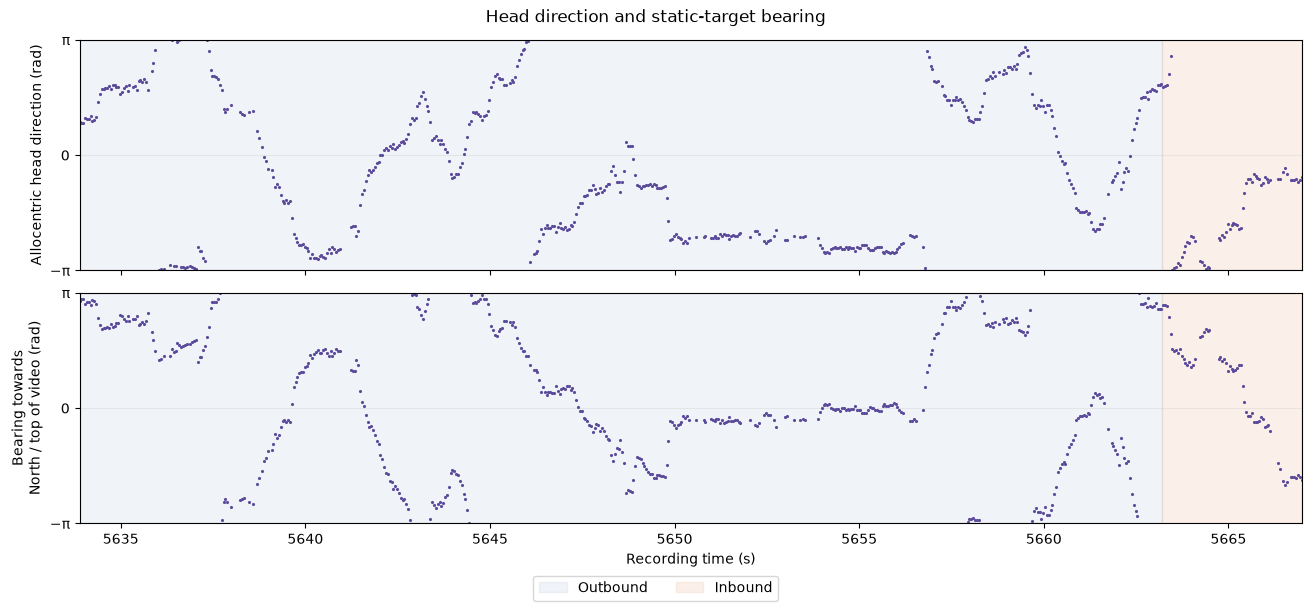

In [7]:
# 4.1 | Return the first selected trial's head-angle figure
head_angles = compute_head_angles(angle_positions, fixed_roi_px)
angle_figure, angle_axes = plot_head_angles(
    head_angles, angle_trials, roi_label=fixed_roi_label,
)
plt.close(angle_figure)  # Display the returned figure once below.
angle_figure


In [10]:
display(occupancy_points)

{'Selected trials': <xarray.DataArray 'position' (time: 36354, space: 2)> Size: 582kB
 nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
 Coordinates:
   * time     (time) float64 291kB 5.633e+03 5.633e+03 ... 7.451e+03 7.451e+03
     session  (time) <U18 3MB '2026-06-21T093349Z' ... '2026-06-21T093349Z'
     mouseID  (time) object 291kB 'MR_M01569515' ... 'MR_M01569515'
     day      (time) object 291kB 'Day21' 'Day21' 'Day21' ... 'Day21' 'Day21'
   * space    (space) <U1 8B 'x' 'y'
 Attributes:
     units:    pixels,
 'Outbound': <xarray.DataArray 'position' (time: 36354, space: 2)> Size: 582kB
 nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
 Coordinates:
   * time     (time) float64 291kB 5.633e+03 5.633e+03 ... 7.451e+03 7.451e+03
     session  (time) <U18 3MB '2026-06-21T093349Z' ... '2026-06-21T093349Z'
     mouseID  (time) object 291kB 'MR_M01569515' ... 'MR_M01569515'
     day      (time) object 291kB 'Day21' 'Day21

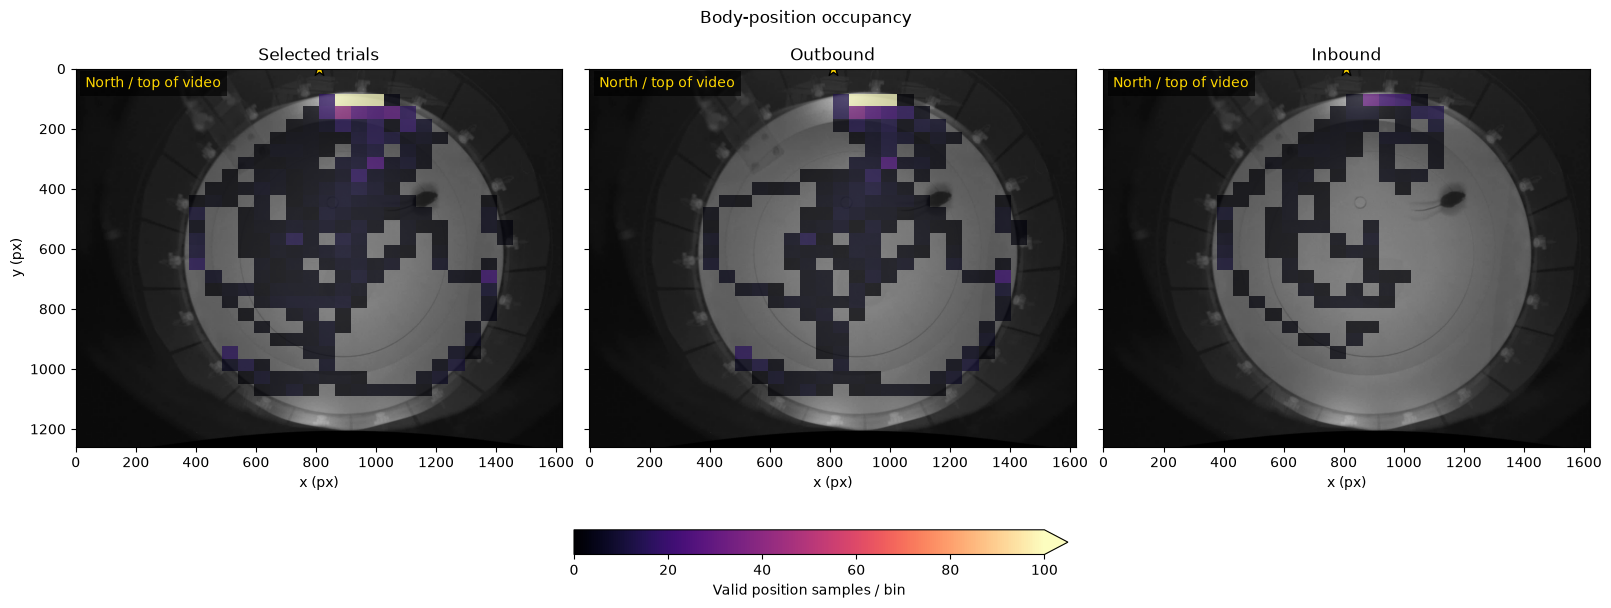

In [8]:
# 4.2 | Return occupancy for the selected trials and their phases
occupancy_figure, occupancy_axes, occupancy = plot_spatial_occupancy(
    occupancy_points, background_frame, fixed_roi_px, roi_label=fixed_roi_label,
    bins=30, vmax=100.0, alpha=0.70,
)
plt.close(occupancy_figure)  # Display the returned figure once below.
occupancy_figure
